In [1]:
import matplotlib.pyplot as plt
import os.path
import seaborn as sns
import torch

from pathlib import Path

from pyro_cases.run import vae_dict

In [2]:
result_dir = Path("/data/scratch/pduan/gcvi_04-16_output/")

In [10]:
elbo_not_converge_cases = 0
favi_not_converge_cases = 0
elbo_invalid_k_hat_cases = 0
favi_invalid_k_hat_cases = 0
result_files = os.listdir(result_dir)
for i, item in enumerate(result_files):
    full_path = result_dir / item
    results = torch.load(full_path, map_location="cpu")
    elbo_not_converge = 0
    favi_not_converge = 0
    elbo_invalid_k_hat = 0
    favi_invalid_k_hat = 0
    elbo_error = ""
    favi_error = ""
    task_name = None
    results_num = len(results)
    for r in results:
        task_name = r["task"]
        if r["elbo_k_hat"] == "elbo_cant_converge" or \
            (torch.isinf(r["elbo_k_hat"]).any() | torch.isnan(r["elbo_k_hat"]).any()):
            elbo_invalid_k_hat += 1
        if r["favi_k_hat"] == "favi_cant_converge" or \
            (torch.isinf(r["favi_k_hat"]).any() | torch.isnan(r["favi_k_hat"]).any()):
            favi_invalid_k_hat += 1

        if "elbo_cant_converge" in r["elbo_test_dict_list"]:
            elbo_not_converge += 1
        if "favi_cant_converge" in r["favi_test_dict_list"]:
            favi_not_converge += 1
        elbo_error = r["elbo_error"]
        favi_error = r["favi_error"]
    if elbo_not_converge > 0:
        elbo_not_converge_cases += 1
    if elbo_invalid_k_hat > 0:
        elbo_invalid_k_hat_cases += 1
    if favi_not_converge > 0:
        favi_not_converge_cases += 1
    if favi_invalid_k_hat > 0:
        favi_invalid_k_hat_cases += 1 
    print("=" * 50)
    print(f"[{i + 1}] task name: {task_name}")
    print(f"elbo can't converge: {elbo_not_converge} / {results_num}")
    print(f"elbo invalid k hat: {elbo_invalid_k_hat} / {results_num}")
    print(f"favi can't converge: {favi_not_converge} / {results_num}")
    print(f"favi invalid k hat: {favi_invalid_k_hat} / {results_num}")
    print(f"elbo error: {elbo_error[:20]}")
    print(f"favi error: {favi_error[:20]}")
print("=" * 100)
print("Summary:")
print(f"elbo not converge cases: {elbo_not_converge_cases} / {len(result_files)} ({elbo_not_converge_cases / len(result_files):.4f})")
print(f"elbo invalid k hat cases: {elbo_invalid_k_hat_cases} / {len(result_files)} ({elbo_invalid_k_hat_cases / len(result_files):.4f})")
print(f"favi not converge cases: {favi_not_converge_cases} / {len(result_files)} ({favi_not_converge_cases / len(result_files):.4f})")
print(f"favi invalid k hat cases: {favi_invalid_k_hat_cases} / {len(result_files)} ({favi_invalid_k_hat_cases / len(result_files):.4f})")

[1] task name: arm_latent_glm
elbo can't converge: 4 / 4
elbo invalid k hat: 4 / 4
favi can't converge: 0 / 4
favi invalid k hat: 0 / 4
elbo error: Expected parameter l
favi error: 
[2] task name: arm_kidiq_multi_preds
elbo can't converge: 0 / 4
elbo invalid k hat: 4 / 4
favi can't converge: 0 / 4
favi invalid k hat: 4 / 4
elbo error: 
favi error: 
[3] task name: arm_ideo_interactions
elbo can't converge: 0 / 4
elbo invalid k hat: 4 / 4
favi can't converge: 0 / 4
favi invalid k hat: 4 / 4
elbo error: 
favi error: 
[4] task name: arm_electric_trpre
elbo can't converge: 0 / 4
elbo invalid k hat: 4 / 4
favi can't converge: 0 / 4
favi invalid k hat: 2 / 4
elbo error: 
favi error: 
[5] task name: bernoulli_glm_raw
elbo can't converge: 0 / 4
elbo invalid k hat: 0 / 4
favi can't converge: 0 / 4
favi invalid k hat: 0 / 4
elbo error: 
favi error: 
[6] task name: arm_electric_1a
elbo can't converge: 0 / 4
elbo invalid k hat: 4 / 4
favi can't converge: 0 / 4
favi invalid k hat: 4 / 4
elbo error: 

In [17]:
def plot_vsbc(vsbc_matrix: torch.Tensor, suptitle):
    theta_dim = vsbc_matrix.shape[0]
    nrows = theta_dim // 4 + 1 if theta_dim % 4 != 0 else theta_dim // 4
    ncols = 4
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3))
    axes = axes.flatten()
    for i, vsbc_samples in enumerate(vsbc_matrix):
        ax = axes[i]
        sns.kdeplot(vsbc_samples, 
                    ax=ax, 
                    clip=(0, 1),
                    fill=True,
                    bw_adjust=0.7)
        ax.axvline(x=0.5, color="red", linestyle="--")
        ax.set_title(f"theta[{i}]")
    fig.suptitle(suptitle)
    fig.tight_layout()
    fig.show()

In [18]:
def print_k_hat_and_vsbc(file_name):
    f_path = result_dir / file_name
    r = torch.load(f_path, map_location="cpu")[0]
    elbo_k_hat = r["elbo_k_hat"]
    favi_k_hat = r["favi_k_hat"]
    elbo_vsbc = r["elbo_vsbc"]
    favi_vsbc = r["favi_vsbc"]
    print(f"elbo k_hat:\n {elbo_k_hat}")
    print(f"elbo k_hat mean: {elbo_k_hat.mean()}")
    print(f"favi k_hat:\n {favi_k_hat}")
    print(f"favi k_hat mean: {favi_k_hat.mean()}")
    print("elbo vsbc:")
    plot_vsbc(elbo_vsbc, suptitle="ELBO")
    print("favi vsbc:")
    plot_vsbc(favi_vsbc, suptitle="FAVI")

elbo k_hat:
 tensor([ 8.5390, 10.4369,  5.0746,  8.1123,  1.7471,  3.8847,  5.2790,  8.0049,
         6.3828,  5.1599,  6.4491,  3.9931,  6.4279,  5.8761,  7.4325,  8.3062,
         4.7732,  4.4136,  3.8832,  8.2226,  5.0537,  5.9429,  4.9977,  3.4705,
         4.0202,  3.1602,  3.1652,  5.3477,  4.5742,  6.0450],
       dtype=torch.float64)
elbo k_hat mean: 5.605868037541708
favi k_hat:
 tensor([ 2.1797e+00, -3.0329e-01,  2.3747e-01, -5.1922e-01, -3.4218e-01,
         1.6231e-01, -2.1525e-01,  3.2220e-01, -5.5847e-01,  1.8180e-01,
        -1.0167e-01,  1.1440e-02, -4.0547e-01, -5.7041e-01,  6.0331e-02,
        -6.8979e-03,  4.1515e-01, -4.6562e-01, -6.7953e-01, -4.0777e-01,
        -1.2713e-01,  9.9423e+00, -2.0092e-01,  4.4027e-01,  1.3462e+01,
         3.8560e+00,  1.1634e-02,  3.5311e-01,  9.0983e+00, -2.5254e-01],
       dtype=torch.float64)
favi k_hat mean: 1.185921568982303
elbo vsbc:
favi vsbc:


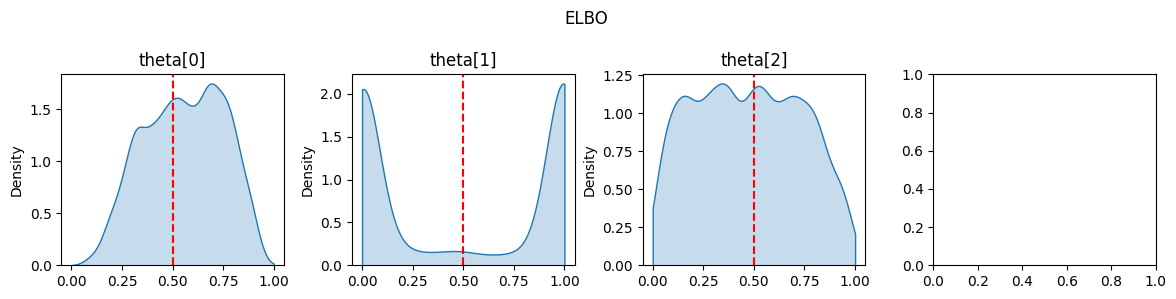

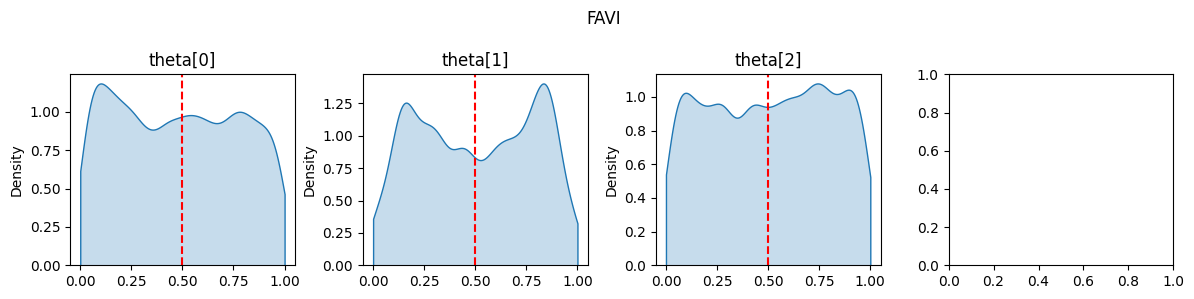

In [21]:
print_k_hat_and_vsbc("pyro_t_arm_earnings1_lr_cosine_annealing_nw_1024_mn_4.pt")